## Medical Referral to Prior Auth Form Automation

## ✅ Goal 1:
You'll:

Upload a PA form (PDF).

Display the PDF page as an image.

Click on the image to record (x, y) coordinates.

Use those coordinates to insert text using reportlab.

## 🔧 Step 1: Install Required Libraries

In [1]:
!pip install PyMuPDF matplotlib reportlab PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.8 MB/s eta 0:00:00


## 📄 Step 2: Upload Your PA PDF Form

In [2]:
from google.colab import files
uploaded = files.upload()


Saving PA.pdf to PA.pdf


## 📸 Step 3: Convert PDF to Image and Show Clickable Page

In [5]:
import fitz  # PyMuPDF
import matplotlib.pyplot as plt

# Load the PDF
pdf_path = list(uploaded.keys())[0] # PA.pdf
doc = fitz.open(pdf_path)

# Render first page
page = doc.load_page(0)
pix = page.get_pixmap()
img = pix.tobytes("png")

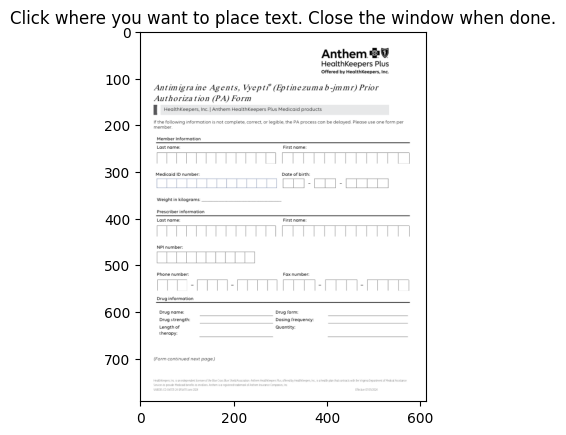

In [6]:
# Display the image and capture clicks
import io
from PIL import Image

img_pil = Image.open(io.BytesIO(img))
fig, ax = plt.subplots()
ax.imshow(img_pil)

coords = []

def onclick(event):
    ix, iy = int(event.xdata), int(event.ydata)
    coords.append((ix, iy))
    print(f"Clicked at: ({ix}, {iy})")

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.title("Click where you want to place text. Close the window when done.")
plt.show()


## ✍️ Step 4: Use Coordinates to Overlay Text
Now that you have your coords list (e.g. [ (100, 700), (100, 680) ]), you can overlay:

📐 Note on Coordinates
Matplotlib (image) origin: top-left (0, 0)

PDF coordinate system origin: bottom-left (0, 0)

So we flip y using: 792 - y (if using letter size 8.5x11 → 612x792)

In [9]:
print(coords)

[]


In [7]:
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import letter
from PyPDF2 import PdfReader, PdfWriter

overlay_path = "overlay.pdf"
final_output = "final_filled_form.pdf"

# Example form fields and values
form_data = {
    "PatientName": "Jane Smith",
    "DOB": "01/01/1980"
}

# Make sure number of fields matches number of coordinates
assert len(coords) == len(form_data)

# Create overlay
c = canvas.Canvas(overlay_path, pagesize=letter)
for (label, value), (x, y) in zip(form_data.items(), coords):
    c.drawString(x, 792 - y, value)  # Flip y-axis for PDF coordinates

c.save()

# Merge overlay with original
reader = PdfReader(pdf_path)
overlay_reader = PdfReader(overlay_path)
writer = PdfWriter()

page = reader.pages[0]
overlay_page = overlay_reader.pages[0]
page.merge_page(overlay_page)
writer.add_page(page)

with open(final_output, "wb") as f:
    writer.write(f)

files.download(final_output)


AssertionError: 

## ✅ 1. Setup & Install Dependencies

In [ ]:
# Install required libraries
!pip install pdfplumber pdfforms llama-index mistralai google-generativeai pypdf

  Using cached pdfplumber-0.11.7-py3-none-any.whl.metadata (42 kB)
  Using cached pdfforms-2.0.0-py2.py3-none-any.whl.metadata (7.5 kB)
  Using cached llama_index-0.12.42-py3-none-any.whl.metadata (12 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.1/374.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.2/304.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.8/266.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.4 MB/s eta 0:00:00
   ━━

In [ ]:
# For OCR fallback (if scanned images are involved)
!apt-get install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!git clone https://github.com/team-headstart/headstarter-mandolin-project.git

Cloning into 'headstarter-mandolin-project'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 0), reused 16 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 19.56 MiB | 21.19 MiB/s, done.
